In [1]:
import pandas as pd
from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from collections import defaultdict
from astropy.coordinates import SkyCoord
import astropy.units as u
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, accuracy_score
)

In [2]:
# Load the FITS catalog from your scratch directory
manga = Table.read("/pscratch/sd/j/jlargett/DESI_SGA_MINE/Sorter/manga-morphology-dl-DR17.fits")
manga

INTID,MANGA_ID,PLATEIFU,OBJID,RA,DEC,Z,DUPL_GR,DUPL_N,DUPL_ID,T-Type,T-Type_std,P_LTG,P_LTG_std,P_S0,P_S0_std,P_edge,P_edge_std,P_bar,P_bar_std,Visual_Class,Visual_Flag
int16,bytes9,bytes15,int64,float64,float64,float64,int16,int16,int16,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int16,int16
1,1-286558,8325-12701,1237661435926544550,210.17634,45.833422,0.04288710891658048,0,0,0,4.221438407897949,0.6632512920115043,0.9802886247634888,0.023341917289120134,0.938228964805603,0.12361474624591347,0.0039536390686407685,0.065356233171725,0.45846888422966003,0.065356233171725,3,0
2,1-274706,8253-12701,1237660634384761005,157.05886,42.96805,0.04496037553087202,0,0,0,4.378849506378174,1.0630811776112241,0.999234676361084,0.0012762211396711856,0.9836623072624207,0.144277846757422,0.9999891519546509,0.00016300611310054642,0.10297111421823502,0.00016300611310054642,3,0
3,1-201874,8938-12701,1237657118405886241,119.75748,30.976025,0.05276287200043103,0,0,0,3.3679091930389404,0.6427940112443938,0.927117645740509,0.12398989623522808,0.8620888590812683,0.12167109396230592,0.6124326288700104,0.146001299579978,0.16775675863027573,0.146001299579978,3,0
4,1-626658,8983-12701,1237667323264368802,203.83021,26.424781,0.02535624535944735,0,0,0,3.3002166748046875,0.7500633033353644,0.9808579385280609,0.023036707681772097,0.9125989377498627,0.1421640087995252,0.006133790244348347,0.02660665703469211,0.18608582764863968,0.02660665703469211,3,0
5,1-24425,8626-12701,1237656529994055837,263.52527,56.799613,0.02923735792806886,0,0,0,-0.22833305597305298,0.5620976832249787,0.062017541378736496,0.0343759162684501,0.2607986405491829,0.20289286953115845,0.03328006900846958,0.07390042108431057,0.157500758767128,0.07390042108431057,1,0
6,1-385070,9501-12701,1237664668424667344,129.89352,25.477089,0.02918049726283862,0,0,0,5.5539751052856445,1.0346164326088745,0.9948531091213226,0.011397733314282586,0.9820498526096344,0.1366270772213304,3.119309752719346e-07,2.5032462500125135e-06,0.06437770463526249,2.5032462500125135e-06,3,0
7,1-455661,8931-12701,1237667442437259402,192.88862,26.769826,0.04561212218107418,0,0,0,3.955049514770508,0.7488214782734656,0.9717792272567749,0.04076767641810579,0.856835663318634,0.13482047899479113,0.0016506986576132476,0.04093541945456329,0.8361897468566895,0.04093541945456329,3,0
8,1-321655,9033-12701,1237662302437179644,221.97538,46.514929,0.08674015114209274,0,0,0,0.6884464621543884,0.7112244616559166,0.43974047899246216,0.22112363537448873,0.7472379207611084,0.15556161435425664,0.0018360039102844894,0.035489573540573555,0.17628274857997894,0.035489573540573555,2,1
9,1-24003,8625-12701,1237651211750932696,257.95754,57.110933,0.03027913690175131,0,0,0,0.07904273271560669,0.6390580005586807,0.19968923181295395,0.20868281671729408,0.4820563644170761,0.15904526176965755,0.28534209728240967,0.13637724989039438,0.9737994968891144,0.13637724989039438,3,1


In [3]:
# Convert to pandas for easier duplicate handling
manga_df = manga.to_pandas()
manga_df

,INTID,MANGA_ID,PLATEIFU,OBJID,RA,DEC,Z,DUPL_GR,DUPL_N,DUPL_ID,...,P_LTG,P_LTG_std,P_S0,P_S0_std,P_edge,P_edge_std,P_bar,P_bar_std,Visual_Class,Visual_Flag
0,1,b'1-286558 ',b'8325-12701 ',1237661435926544550,210.176340,45.833422,0.042887,0,0,0,...,0.980289,0.023342,0.938229,0.123615,0.003954,0.065356,0.458469,0.065356,3,0
1,2,b'1-274706 ',b'8253-12701 ',1237660634384761005,157.058860,42.968050,0.044960,0,0,0,...,0.999235,0.001276,0.983662,0.144278,0.999989,0.000163,0.102971,0.000163,3,0
2,3,b'1-201874 ',b'8938-12701 ',1237657118405886241,119.757480,30.976025,0.052763,0,0,0,...,0.927118,0.123990,0.862089,0.121671,0.612433,0.146001,0.167757,0.146001,3,0
3,4,b'1-626658 ',b'8983-12701 ',1237667323264368802,203.830210,26.424781,0.025356,0,0,0,...,0.980858,0.023037,0.912599,0.142164,0.006134,0.026607,0.186086,0.026607,3,0
4,5,b'1-24425 ',b'8626-12701 ',1237656529994055837,263.525270,56.799613,0.029237,0,0,0,...,0.062018,0.034376,0.260799,0.202893,0.033280,0.073900,0.157501,0.073900,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10288,10673,b'1-628628 ',b'8309-3703 ',587735665305452606,210.623550,54.270943,0.000507,0,0,0,...,0.490860,0.255234,0.562321,0.069861,0.257023,0.136581,0.384835,0.136581,3,1
10289,10674,b'1-409209 ',b'8445-3701 ',587738950957858835,205.642456,35.020329,0.024267,0,0,0,...,0.602385,0.223111,0.574921,0.126489,0.296941,0.131451,0.248840,0.131451,3,1
10290,10675,b'1-605161 ',b'8722-3701 ',587725980687859744,124.831589,50.005749,0.001806,0,0,0,...,0.994923,0.028970,0.666524,0.113882,0.007348,0.031560,0.364009,0.031560,3,1
10291,10676,b'1-604984 ',b'9503-12705 ',588297863635075268,121.172829,24.870420,0.016581,0,0,0,...,0.206619,0.142022,0.574407,0.071702,0.225886,0.096069,0.331707,0.096069,3,1


In [4]:
# Check for duplicate MANGA_IDs
duplicates = manga_df[manga_df.duplicated(subset='MANGA_ID', keep=False)]
duplicates

,INTID,MANGA_ID,PLATEIFU,OBJID,RA,DEC,Z,DUPL_GR,DUPL_N,DUPL_ID,...,P_LTG,P_LTG_std,P_S0,P_S0_std,P_edge,P_edge_std,P_bar,P_bar_std,Visual_Class,Visual_Flag
10,11,b'1-113567 ',b'7815-12701 ',1237653009194615943,318.026430,11.345157,0.016732,1,2,1,...,0.992341,0.008384,0.939691,0.125609,0.006808,0.017512,0.606143,0.017512,3,1
66,69,b'1-209823 ',b'9031-12701 ',1237659324952150186,238.948510,44.668543,0.039852,2,2,1,...,0.996540,0.004960,0.958202,0.130228,0.000277,0.002718,0.136450,0.002718,3,0
101,104,b'1-277691 ',b'8274-12701 ',1237661967423438982,164.585190,40.788234,0.025577,3,2,1,...,0.978165,0.016133,0.990275,0.124973,0.888338,0.067307,0.339851,0.067307,3,0
132,135,b'1-134760 ',b'8555-12701 ',1237665355623301303,245.362220,42.761290,0.135481,4,2,1,...,0.086726,0.119204,0.134932,0.183628,0.298674,0.106549,0.240673,0.106549,1,0
135,138,b'1-235398 ',b'8326-12701 ',1237658205593403484,213.149190,47.253058,0.028065,5,2,1,...,0.999010,0.002651,0.986024,0.126930,0.016403,0.016871,0.777899,0.016871,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10050,10281,b'1-634132 ',b'11948-12703 ',1237659162816020815,250.094528,33.679752,0.030861,139,2,2,...,0.995770,0.010764,0.928200,0.143914,0.030395,0.021443,0.414037,0.021443,3,1
10241,10508,b'1-320681 ',b'11827-3704 ',1237662300824141919,213.813080,47.873348,0.027855,40,2,2,...,0.007376,0.007791,0.390751,0.169950,0.038653,0.043339,0.128063,0.043339,2,0
10243,10560,b'1-176448 ',b'11949-1902 ',1237655374113341859,253.677353,34.728645,0.029092,39,2,2,...,0.498649,0.167109,0.852536,0.157040,0.010400,0.007157,0.811093,0.007157,2,0
10244,10561,b'1-176444 ',b'11949-3703 ',1237655374113341634,253.730560,34.719540,0.030231,78,2,2,...,0.028754,0.041525,0.189819,0.158115,0.004927,0.013833,0.383604,0.013833,1,0


In [5]:
# Remove duplicate MANGA_IDs, keeping the first
manga_df_unique = manga_df.drop_duplicates(subset='MANGA_ID', keep='first')
manga_df_unique

,INTID,MANGA_ID,PLATEIFU,OBJID,RA,DEC,Z,DUPL_GR,DUPL_N,DUPL_ID,...,P_LTG,P_LTG_std,P_S0,P_S0_std,P_edge,P_edge_std,P_bar,P_bar_std,Visual_Class,Visual_Flag
0,1,b'1-286558 ',b'8325-12701 ',1237661435926544550,210.176340,45.833422,0.042887,0,0,0,...,0.980289,0.023342,0.938229,0.123615,0.003954,0.065356,0.458469,0.065356,3,0
1,2,b'1-274706 ',b'8253-12701 ',1237660634384761005,157.058860,42.968050,0.044960,0,0,0,...,0.999235,0.001276,0.983662,0.144278,0.999989,0.000163,0.102971,0.000163,3,0
2,3,b'1-201874 ',b'8938-12701 ',1237657118405886241,119.757480,30.976025,0.052763,0,0,0,...,0.927118,0.123990,0.862089,0.121671,0.612433,0.146001,0.167757,0.146001,3,0
3,4,b'1-626658 ',b'8983-12701 ',1237667323264368802,203.830210,26.424781,0.025356,0,0,0,...,0.980858,0.023037,0.912599,0.142164,0.006134,0.026607,0.186086,0.026607,3,0
4,5,b'1-24425 ',b'8626-12701 ',1237656529994055837,263.525270,56.799613,0.029237,0,0,0,...,0.062018,0.034376,0.260799,0.202893,0.033280,0.073900,0.157501,0.073900,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10288,10673,b'1-628628 ',b'8309-3703 ',587735665305452606,210.623550,54.270943,0.000507,0,0,0,...,0.490860,0.255234,0.562321,0.069861,0.257023,0.136581,0.384835,0.136581,3,1
10289,10674,b'1-409209 ',b'8445-3701 ',587738950957858835,205.642456,35.020329,0.024267,0,0,0,...,0.602385,0.223111,0.574921,0.126489,0.296941,0.131451,0.248840,0.131451,3,1
10290,10675,b'1-605161 ',b'8722-3701 ',587725980687859744,124.831589,50.005749,0.001806,0,0,0,...,0.994923,0.028970,0.666524,0.113882,0.007348,0.031560,0.364009,0.031560,3,1
10291,10676,b'1-604984 ',b'9503-12705 ',588297863635075268,121.172829,24.870420,0.016581,0,0,0,...,0.206619,0.142022,0.574407,0.071702,0.225886,0.096069,0.331707,0.096069,3,1


In [6]:
# Check to confirm all are now unique
assert manga_df_unique['MANGA_ID'].is_unique, "Duplicates still present!"

In [7]:
ssl_classifications = pd.read_csv('/global/cfs/cdirs/desi/science/td/pv/SGA2020/classifications_SGA2020_and_vi.csv')
print(ssl_classifications.head())

   SGA_ID Classification
0     2.0         Spiral
1     3.0         Spiral
2     4.0      Irregular
3     7.0         Spiral
4    18.0     Elliptical


In [8]:
sga = Table.read('/global/cfs/cdirs/cosmo/data/sga/2020/SGA-2020.fits', hdu=1)
sga_df = sga.to_pandas()
sga_df

,SGA_ID,SGA_GALAXY,GALAXY,PGC,RA_LEDA,DEC_LEDA,MORPHTYPE,PA_LEDA,D25_LEDA,BA_LEDA,...,R_COG_PARAMS_M0,R_COG_PARAMS_ALPHA1,R_COG_PARAMS_ALPHA2,R_COG_PARAMS_CHI2,Z_COG_PARAMS_MTOT,Z_COG_PARAMS_M0,Z_COG_PARAMS_ALPHA1,Z_COG_PARAMS_ALPHA2,Z_COG_PARAMS_CHI2,ELLIPSEBIT
0,2,b'SGA-2020 2',b'PGC1283207',1283207,228.377086,5.423202,b'S?',152.199997,0.363078,0.724436,...,0.264044,0.345595,3.303355,0.003811,15.195567,0.298264,0.300107,3.233377,0.011724,0
1,3,b'SGA-2020 3',b'PGC1310416',1310416,202.544438,6.934594,b'Sc',159.259995,0.401791,0.781628,...,0.876432,0.273606,2.499542,0.493439,15.235263,1.309869,0.178668,2.175050,0.203912,0
2,4,b'SGA-2020 4',b'SDSSJ145059.93+135143.0',4435547,222.749787,13.861911,b'S?',44.570000,0.333426,0.663743,...,0.488582,0.278250,3.214446,1.373326,16.807674,0.517704,0.322646,2.900518,1.805409,0
3,7,b'SGA-2020 7',b'PGC1742504',1742504,182.088808,25.602276,b'Sbc',84.970001,0.548277,0.251189,...,0.765731,0.522855,2.304599,0.006013,15.191324,1.040820,0.329563,2.152033,0.004725,0
4,18,b'SGA-2020 18',b'2MASXJ12340801+4535444',3550748,188.533553,45.595643,b'E',168.649994,0.530884,0.695024,...,0.324728,1.743924,2.177483,0.023486,15.124181,0.165473,1.469468,3.394879,0.028654,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
383615,5005230,b'SGA-2020 5005230',b'DR8-0774m270-618',-1,77.397511,-27.106348,b'PSF',0.000000,0.332000,1.000000,...,0.231687,0.219425,3.111871,0.016901,16.022186,0.241948,0.201020,3.134553,0.011278,0
383616,5005238,b'SGA-2020 5005238',b'DR8-3541p242-2263',-1,354.025406,24.266276,b'PSF',0.000000,0.553000,1.000000,...,0.241669,0.313603,2.891678,0.068157,15.030018,0.215990,0.324286,2.999769,0.032022,0
383617,5005241,b'SGA-2020 5005241',b'DR8-3598p237-618',-1,359.778524,23.672069,b'PSF',0.000000,0.647000,1.000000,...,0.150522,0.867359,3.746000,0.005017,15.713827,0.251672,0.725019,3.094475,0.004562,0
383618,5005244,b'SGA-2020 5005244',b'DR8-1933p245-3598',-1,193.433580,24.573039,b'PSF',0.000000,0.508000,1.000000,...,8809.708984,0.000040,0.644355,0.112737,15.642013,9365.626953,0.000035,0.740361,0.139232,0


In [9]:
# Merge ssl and sga_df on SGA_ID
ssl_and_sga = ssl_classifications.merge(sga_df, on='SGA_ID', how='inner')
ssl_and_sga

,SGA_ID,Classification,SGA_GALAXY,GALAXY,PGC,RA_LEDA,DEC_LEDA,MORPHTYPE,PA_LEDA,D25_LEDA,...,R_COG_PARAMS_M0,R_COG_PARAMS_ALPHA1,R_COG_PARAMS_ALPHA2,R_COG_PARAMS_CHI2,Z_COG_PARAMS_MTOT,Z_COG_PARAMS_M0,Z_COG_PARAMS_ALPHA1,Z_COG_PARAMS_ALPHA2,Z_COG_PARAMS_CHI2,ELLIPSEBIT
0,2.0,Spiral,b'SGA-2020 2',b'PGC1283207',1283207,228.377086,5.423202,b'S?',152.199997,0.363078,...,0.264044,0.345595,3.303355,0.003811,15.195567,0.298264,0.300107,3.233377,0.011724,0
1,3.0,Spiral,b'SGA-2020 3',b'PGC1310416',1310416,202.544438,6.934594,b'Sc',159.259995,0.401791,...,0.876432,0.273606,2.499542,0.493439,15.235263,1.309869,0.178668,2.175050,0.203912,0
2,4.0,Irregular,b'SGA-2020 4',b'SDSSJ145059.93+135143.0',4435547,222.749787,13.861911,b'S?',44.570000,0.333426,...,0.488582,0.278250,3.214446,1.373326,16.807674,0.517704,0.322646,2.900518,1.805409,0
3,7.0,Spiral,b'SGA-2020 7',b'PGC1742504',1742504,182.088808,25.602276,b'Sbc',84.970001,0.548277,...,0.765731,0.522855,2.304599,0.006013,15.191324,1.040820,0.329563,2.152033,0.004725,0
4,18.0,Elliptical,b'SGA-2020 18',b'2MASXJ12340801+4535444',3550748,188.533553,45.595643,b'E',168.649994,0.530884,...,0.324728,1.743924,2.177483,0.023486,15.124181,0.165473,1.469468,3.394879,0.028654,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
383613,920263.0,Irregular,b'SGA-2020 920263',b'PGC037814',37814,179.990550,49.564227,b'I',40.169998,0.726106,...,2.511431,0.528198,1.493521,0.432771,15.130772,0.325994,6.646182,4.300548,4.242318,0
383614,1064408.0,Irregular,b'SGA-2020 1064408',b'PGC039905',39905,185.303166,8.963172,b'I',39.450001,0.554626,...,1.005913,1.768526,2.073922,5.624894,15.588434,0.985109,1.771035,2.104439,4.199859,0
383615,224150.0,Irregular,b'SGA-2020 224150',b'PGC1968108',1968108,186.525125,31.859753,b'I',38.869999,0.467735,...,1.314282,1.141052,1.542372,0.191869,15.633162,1.335702,1.202724,1.544921,0.440248,0
383616,1321251.0,Irregular,b'SGA-2020 1321251',b'PGC2546877',2546877,163.461745,56.758292,b'I',27.790001,0.392645,...,0.990594,0.307111,2.027966,0.178716,16.734728,0.314893,0.368776,3.940005,0.936376,0


In [10]:
# SkyCoord objects — fix is removing `.values`
manga_coords = SkyCoord(ra=manga["RA"] * u.deg,
                     dec=manga["DEC"] * u.deg)

sga_coords = SkyCoord(ra=sga["RA"] * u.deg,
                      dec=sga["DEC"] * u.deg)

# Crossmatch within 10 arcsec
idx_manga, idx_sga, sep2d, _ = manga_coords.search_around_sky(sga_coords, 10 * u.arcsec)

print(f"Number of matched DL–SGA galaxies: {len(idx_manga)}")

Number of matched DL–SGA galaxies: 8459


In [11]:
# Create DataFrame from matched indices
sga_ids_native = np.array(sga["SGA_ID"][idx_manga]).astype(np.int64) # Use NumPy's .astype() to convert SGA_ID to native-endian

matched_df = pd.DataFrame({
    "SGA_ID": sga_ids_native,
    "MANGA_ID": manga["MANGA_ID"][idx_sga],
    "Separation_arcsec": sep2d.arcsec
})

# Keep only the closest match for each object
matched_df = matched_df.sort_values(by='Separation_arcsec')  # smallest sep first
matched_df = matched_df.drop_duplicates(subset='MANGA_ID', keep='first')
matched_df = matched_df.drop_duplicates(subset='SGA_ID', keep='first')

print(f"After deduplication, matched MANGA objects: {len(matched_df)}")
print(matched_df.head(11))

After deduplication, matched MANGA objects: 8277
       SGA_ID      MANGA_ID  Separation_arcsec
5383   908235  b'1-145978 '           0.001532
7757  1287351  b'1-259136 '           0.001604
4925   824104  b'1-231892 '           0.001686
6590  1101148  b'1-403720 '           0.001865
5876   994539  b'1-567244 '           0.002124
4228   724754  b'1-230926 '           0.002492
1950   298911  b'1-379545 '           0.002699
5125   839534  b'1-556855 '           0.002807
4564   752244  b'1-247758 '           0.002926
991    129955  b'1-114919 '           0.002954
3351   556418  b'1-234341 '           0.003070


In [12]:
# How many unique MAGNA sources are matched?
unique_magna_ids = matched_df['MANGA_ID'].nunique()
print(f"Unique matched MAGNA entries: {unique_magna_ids}")

Unique matched MAGNA entries: 8277


In [13]:
def group_ssl(label):
    if label in ['Spiral', 'Irregular']:
        return 'LTG'
    elif label in ['Elliptical', 'Lenticular', 'Unclassified']:
        return label
    else:
        return 'Unknown'

ssl_classifications['Classification_grouped'] = ssl_classifications['Classification'].apply(group_ssl)

In [14]:
# Merge with morphology classification on SGA_ID
merged_df = matched_df.merge(ssl_classifications[["SGA_ID", "Classification", "Classification_grouped"]], on="SGA_ID", how="left")
print(merged_df.head(10))
print(merged_df['Classification_grouped'].value_counts(dropna=False))
print(len(merged_df))

    SGA_ID      MANGA_ID  Separation_arcsec Classification  \
0   908235  b'1-145978 '           0.001532     Lenticular   
1  1287351  b'1-259136 '           0.001604     Elliptical   
2   824104  b'1-231892 '           0.001686      Irregular   
3  1101148  b'1-403720 '           0.001865   Unclassified   
4   994539  b'1-567244 '           0.002124     Lenticular   
5   724754  b'1-230926 '           0.002492     Elliptical   
6   298911  b'1-379545 '           0.002699     Elliptical   
7   839534  b'1-556855 '           0.002807     Elliptical   
8   752244  b'1-247758 '           0.002926   Unclassified   
9   129955  b'1-114919 '           0.002954   Unclassified   

  Classification_grouped  
0             Lenticular  
1             Elliptical  
2                    LTG  
3           Unclassified  
4             Lenticular  
5             Elliptical  
6             Elliptical  
7             Elliptical  
8           Unclassified  
9           Unclassified  
Classification_group

In [15]:
visual = manga_df_unique[manga_df_unique['Visual_Flag'] == 0]

def visual_label(vc):
    return {
        1: 'Elliptical',
        2: 'Lenticular',
        3: 'LTG',  # stands for Spirals + Irregulars
        0: 'Unclassified'
    }.get(vc, 'Unknown')

visual['morph_class'] = visual['Visual_Class'].apply(visual_label)
manga_df_unique['morph_class'] = manga_df_unique['Visual_Class'].apply(visual_label)

print(len(visual['morph_class']))
print(len(manga_df_unique['morph_class']))

8747
10138


/tmp/ipykernel_306058/2186137740.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  visual['morph_class'] = visual['Visual_Class'].apply(visual_label)
/tmp/ipykernel_306058/2186137740.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  manga_df_unique['morph_class'] = manga_df_unique['Visual_Class'].apply(visual_label)


In [16]:
visual

,INTID,MANGA_ID,PLATEIFU,OBJID,RA,DEC,Z,DUPL_GR,DUPL_N,DUPL_ID,...,P_LTG_std,P_S0,P_S0_std,P_edge,P_edge_std,P_bar,P_bar_std,Visual_Class,Visual_Flag,morph_class
0,1,b'1-286558 ',b'8325-12701 ',1237661435926544550,210.176340,45.833422,0.042887,0,0,0,...,0.023342,0.938229,0.123615,0.003954,0.065356,0.458469,0.065356,3,0,LTG
1,2,b'1-274706 ',b'8253-12701 ',1237660634384761005,157.058860,42.968050,0.044960,0,0,0,...,0.001276,0.983662,0.144278,0.999989,0.000163,0.102971,0.000163,3,0,LTG
2,3,b'1-201874 ',b'8938-12701 ',1237657118405886241,119.757480,30.976025,0.052763,0,0,0,...,0.123990,0.862089,0.121671,0.612433,0.146001,0.167757,0.146001,3,0,LTG
3,4,b'1-626658 ',b'8983-12701 ',1237667323264368802,203.830210,26.424781,0.025356,0,0,0,...,0.023037,0.912599,0.142164,0.006134,0.026607,0.186086,0.026607,3,0,LTG
4,5,b'1-24425 ',b'8626-12701 ',1237656529994055837,263.525270,56.799613,0.029237,0,0,0,...,0.034376,0.260799,0.202893,0.033280,0.073900,0.157501,0.073900,1,0,Elliptical
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10258,10595,b'1-29692 ',b'8654-6103 ',1237666408440267040,355.089417,0.269481,0.133236,0,0,0,...,0.063319,0.142903,0.158426,0.064993,0.091778,0.079058,0.091778,1,0,Elliptical
10259,10596,b'1-107040 ',b'8654-6104 ',1237663784195326143,355.280212,0.095239,0.068676,0,0,0,...,0.006959,0.098934,0.163340,0.035423,0.056498,0.021853,0.056498,1,0,Elliptical
10260,10597,b'1-29577 ',b'8654-9101 ',1237663784195260614,355.100525,0.002272,0.070060,0,0,0,...,0.007588,0.159914,0.147132,0.040844,0.030819,0.014131,0.030819,1,0,Elliptical
10261,10598,b'1-29707 ',b'8654-9102 ',1237666408440463588,355.608459,0.255993,0.021869,0,0,0,...,0.001057,0.955950,0.143417,0.999984,0.000569,0.323964,0.000569,3,0,LTG


In [17]:
manga_df_unique

,INTID,MANGA_ID,PLATEIFU,OBJID,RA,DEC,Z,DUPL_GR,DUPL_N,DUPL_ID,...,P_LTG_std,P_S0,P_S0_std,P_edge,P_edge_std,P_bar,P_bar_std,Visual_Class,Visual_Flag,morph_class
0,1,b'1-286558 ',b'8325-12701 ',1237661435926544550,210.176340,45.833422,0.042887,0,0,0,...,0.023342,0.938229,0.123615,0.003954,0.065356,0.458469,0.065356,3,0,LTG
1,2,b'1-274706 ',b'8253-12701 ',1237660634384761005,157.058860,42.968050,0.044960,0,0,0,...,0.001276,0.983662,0.144278,0.999989,0.000163,0.102971,0.000163,3,0,LTG
2,3,b'1-201874 ',b'8938-12701 ',1237657118405886241,119.757480,30.976025,0.052763,0,0,0,...,0.123990,0.862089,0.121671,0.612433,0.146001,0.167757,0.146001,3,0,LTG
3,4,b'1-626658 ',b'8983-12701 ',1237667323264368802,203.830210,26.424781,0.025356,0,0,0,...,0.023037,0.912599,0.142164,0.006134,0.026607,0.186086,0.026607,3,0,LTG
4,5,b'1-24425 ',b'8626-12701 ',1237656529994055837,263.525270,56.799613,0.029237,0,0,0,...,0.034376,0.260799,0.202893,0.033280,0.073900,0.157501,0.073900,1,0,Elliptical
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10288,10673,b'1-628628 ',b'8309-3703 ',587735665305452606,210.623550,54.270943,0.000507,0,0,0,...,0.255234,0.562321,0.069861,0.257023,0.136581,0.384835,0.136581,3,1,LTG
10289,10674,b'1-409209 ',b'8445-3701 ',587738950957858835,205.642456,35.020329,0.024267,0,0,0,...,0.223111,0.574921,0.126489,0.296941,0.131451,0.248840,0.131451,3,1,LTG
10290,10675,b'1-605161 ',b'8722-3701 ',587725980687859744,124.831589,50.005749,0.001806,0,0,0,...,0.028970,0.666524,0.113882,0.007348,0.031560,0.364009,0.031560,3,1,LTG
10291,10676,b'1-604984 ',b'9503-12705 ',588297863635075268,121.172829,24.870420,0.016581,0,0,0,...,0.142022,0.574407,0.071702,0.225886,0.096069,0.331707,0.096069,3,1,LTG


In [20]:
# Combine the galaxies that are confidently visually classified with the galaxies that are in the SGA
filtered_df = merged_df.merge(visual[['MANGA_ID']], on='MANGA_ID', how='inner')
filtered_df

,SGA_ID,MANGA_ID,Separation_arcsec,Classification,Classification_grouped
0,908235,b'1-145978 ',0.001532,Lenticular,Lenticular
1,1287351,b'1-259136 ',0.001604,Elliptical,Elliptical
2,824104,b'1-231892 ',0.001686,Irregular,LTG
3,1101148,b'1-403720 ',0.001865,Unclassified,Unclassified
4,994539,b'1-567244 ',0.002124,Lenticular,Lenticular
...,...,...,...,...,...
7381,251450,b'1-131279 ',7.867871,Irregular,LTG
7382,419368,b'1-23610 ',7.914843,Irregular,LTG
7383,953908,b'1-163963 ',8.273804,Spiral,LTG
7384,205931,b'1-25771 ',8.404078,Elliptical,Elliptical


In [21]:
filtered_df = filtered_df.merge(manga_df_unique[['MANGA_ID', 'morph_class']],on='MANGA_ID', how='left')
filtered_df

,SGA_ID,MANGA_ID,Separation_arcsec,Classification,Classification_grouped,morph_class
0,908235,b'1-145978 ',0.001532,Lenticular,Lenticular,LTG
1,1287351,b'1-259136 ',0.001604,Elliptical,Elliptical,Elliptical
2,824104,b'1-231892 ',0.001686,Irregular,LTG,LTG
3,1101148,b'1-403720 ',0.001865,Unclassified,Unclassified,Elliptical
4,994539,b'1-567244 ',0.002124,Lenticular,Lenticular,LTG
...,...,...,...,...,...,...
7381,251450,b'1-131279 ',7.867871,Irregular,LTG,LTG
7382,419368,b'1-23610 ',7.914843,Irregular,LTG,Lenticular
7383,953908,b'1-163963 ',8.273804,Spiral,LTG,LTG
7384,205931,b'1-25771 ',8.404078,Elliptical,Elliptical,Lenticular


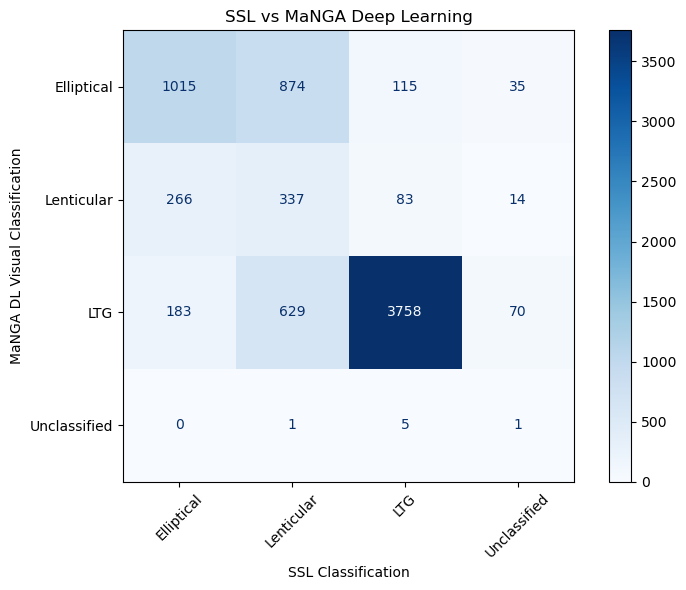

In [23]:
manga_dl = filtered_df['morph_class']
ssl_clas = filtered_df['Classification_grouped']

labels = ['Elliptical', 'Lenticular', 'LTG', 'Unclassified']
cm = confusion_matrix(manga_dl, ssl_clas, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap='Blues')

# Customize labels and title
ax.set_title("SSL vs MaNGA Deep Learning")
ax.set_xlabel("SSL Classification")
ax.set_ylabel("MaNGA DL Visual Classification")

plt.tight_layout()
plt.show()

In [24]:
print("\nClassification Report:")
print(classification_report(filtered_df['morph_class'],
                            filtered_df['Classification_grouped'],
                            labels=labels,
                            digits=2))


Classification Report:
              precision    recall  f1-score   support

  Elliptical       0.69      0.50      0.58      2039
  Lenticular       0.18      0.48      0.27       700
         LTG       0.95      0.81      0.87      4640
Unclassified       0.01      0.14      0.02         7

    accuracy                           0.69      7386
   macro avg       0.46      0.48      0.43      7386
weighted avg       0.80      0.69      0.73      7386



In [25]:
def to_etg_ltg(label):
    if label in ['Elliptical', 'Lenticular']:
        return 'ETG'
    elif label == 'LTG':
        return 'LTG'
    elif label == 'Unclassified':
        return 'Unclassified'
    else:
        return 'Unknown'

filtered_df['morph_class_grouped'] = filtered_df['morph_class'].apply(to_etg_ltg)

In [26]:
filtered_df['ssl_grouped'] = filtered_df['Classification_grouped'].apply(to_etg_ltg)

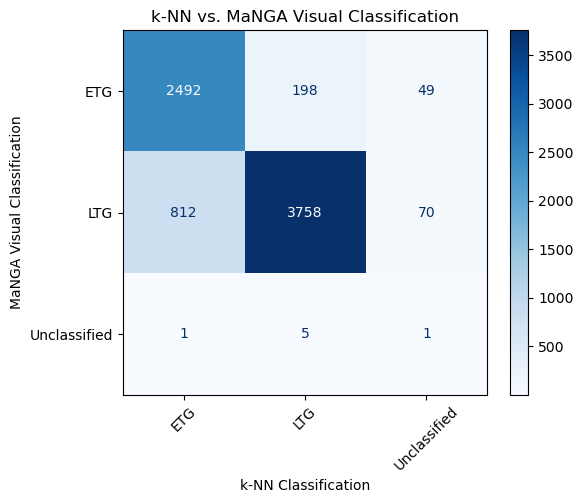

In [27]:
labels = ['ETG', 'LTG', 'Unclassified']
cm = confusion_matrix(
    filtered_df['morph_class_grouped'],
    filtered_df['ssl_grouped'],
    labels=labels
)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
ax.set_title("k-NN vs. MaNGA Visual Classification")
ax.set_xlabel("k-NN Classification")
ax.set_ylabel("MaNGA Visual Classification")
plt.tight_layout()

#plt.savefig('/pscratch/sd/j/jlargett/DESI_SGA_MINE/Sorter/Paper_Figures/sslvmagnavc.png')
plt.show()

In [28]:
print("\nClassification Report:")
print(classification_report(filtered_df['morph_class_grouped'],
                            filtered_df['ssl_grouped'],
                            labels=labels,
                            digits=2))


Classification Report:
              precision    recall  f1-score   support

         ETG       0.75      0.91      0.82      2739
         LTG       0.95      0.81      0.87      4640
Unclassified       0.01      0.14      0.02         7

    accuracy                           0.85      7386
   macro avg       0.57      0.62      0.57      7386
weighted avg       0.88      0.85      0.85      7386



In [29]:
## Using Deep Learning Results

In [30]:
def dl_classification(row):
    if row['T-Type'] > 0 and row['P_LTG'] >= 0.5:
        return 'LTG'  # Spiral/Irregular
    elif row['T-Type'] <= 0 and row['P_S0'] > 0.5 and row['P_LTG'] < 0.5:
        return 'ETG'  # S0-like (DL confidence in S0)
    elif row['T-Type'] <= 0 and row['P_S0'] <= 0.5 and row['P_LTG'] < 0.5:
        return 'ETG'  # Elliptical
    else:
        return 'Unclassified'

In [31]:
manga_df_unique['dl_grouped'] = manga_df_unique.apply(dl_classification, axis=1)

/tmp/ipykernel_306058/3552125451.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  manga_df_unique['dl_grouped'] = manga_df_unique.apply(dl_classification, axis=1)


In [32]:
merged_df['MANGA_ID'] = merged_df['MANGA_ID'].astype(str).str.strip()
manga_df_unique['MANGA_ID'] = manga_df_unique['MANGA_ID'].astype(str).str.strip()

merged_df = merged_df.merge(
    manga_df_unique[['MANGA_ID', 'dl_grouped']],
    on='MANGA_ID',
    how='left'
)

/tmp/ipykernel_306058/2899692974.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  manga_df_unique['MANGA_ID'] = manga_df_unique['MANGA_ID'].astype(str).str.strip()


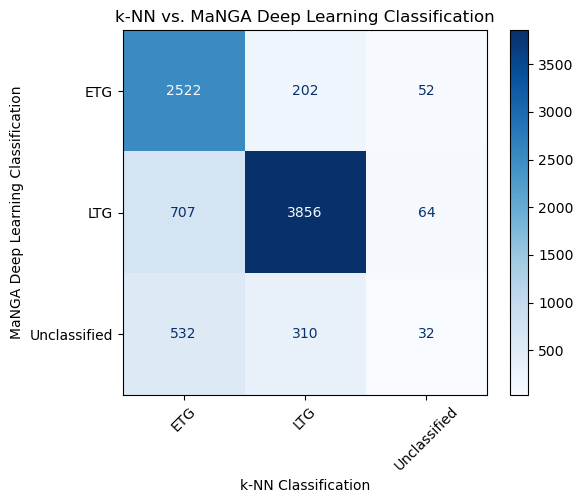

In [36]:
merged_df['ssl_grouped'] = merged_df['Classification_grouped'].apply(to_etg_ltg)

labels = ['ETG', 'LTG', 'Unclassified']
cm = confusion_matrix(
    merged_df['dl_grouped'],
    merged_df['ssl_grouped'],
    labels=['ETG', 'LTG', 'Unclassified']
)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
ax.set_title("k-NN vs. MaNGA Deep Learning Classification")
ax.set_xlabel("k-NN Classification")
ax.set_ylabel("MaNGA Deep Learning Classification")
plt.tight_layout()

#plt.savefig('/pscratch/sd/j/jlargett/DESI_SGA_MINE/Sorter/Paper_Figures/sslvmagnadl.png')
plt.show()

In [35]:
print("\nClassification Report:")
print(classification_report(merged_df['dl_grouped'],
                            merged_df['ssl_grouped'],
                            labels=labels,
                            digits=2))


Classification Report:
              precision    recall  f1-score   support

         ETG       0.67      0.91      0.77      2776
         LTG       0.88      0.83      0.86      4627
Unclassified       0.22      0.04      0.06       874

    accuracy                           0.77      8277
   macro avg       0.59      0.59      0.56      8277
weighted avg       0.74      0.77      0.74      8277

